In [1]:
words = open('names.txt', 'r').read().split('\n')

In [ ]:
names = [word.strip().lower() for word in words]
len(names)

30274

In [3]:
max(len(name) for name in names)

15

In [4]:
b = {}
for n in names:
    chs = ['<S>'] + list(n) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) +1
        

In [5]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('a', '<E>'), 8159),
 (('a', 'n'), 5182),
 (('e', '<E>'), 4806),
 (('n', '<E>'), 4762),
 (('a', 'r'), 3419),
 (('e', 'l'), 3308),
 (('<S>', 'a'), 3223),
 (('r', 'i'), 2914),
 (('n', 'a'), 2914),
 (('h', 'a'), 2662),
 (('l', 'e'), 2569),
 (('e', 'n'), 2482),
 (('m', 'a'), 2457),
 (('<S>', 's'), 2447),
 (('<S>', 'm'), 2414),
 (('o', 'n'), 2382),
 (('<S>', 'j'), 2343),
 (('l', 'a'), 2342),
 (('i', 'a'), 2282),
 (('e', 'r'), 2262),
 (('a', 'l'), 2261),
 (('r', 'a'), 2232),
 (('s', 'h'), 2194),
 (('i', 'n'), 2191),
 (('<S>', 'k'), 2176),
 (('l', 'i'), 2168),
 (('n', 'e'), 2132),
 (('<S>', 'd'), 1862),
 (('<S>', 'c'), 1839),
 (('y', '<E>'), 1834),
 (('<S>', 'l'), 1753),
 (('<S>', 't'), 1708),
 (('n', 'i'), 1695),
 (('i', 'e'), 1675),
 (('r', 'e'), 1662),
 (('t', 'a'), 1636),
 (('i', '<E>'), 1601),
 (('n', 'n'), 1597),
 (('i', 's'), 1585),
 (('l', '<E>'), 1530),
 (('d', 'a'), 1523),
 (('l', 'l'), 1462),
 (('d', 'e'), 1439),
 (('h', '<E>'), 1421),
 (('<S>', 'r'), 1398),
 (('j', 'a'), 1387),


In [6]:
import torch 

In [7]:
N = torch.zeros ((27, 27), dtype=torch.int32)


In [9]:
chars = sorted(list(set(''.join(names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [10]:
for w in names:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

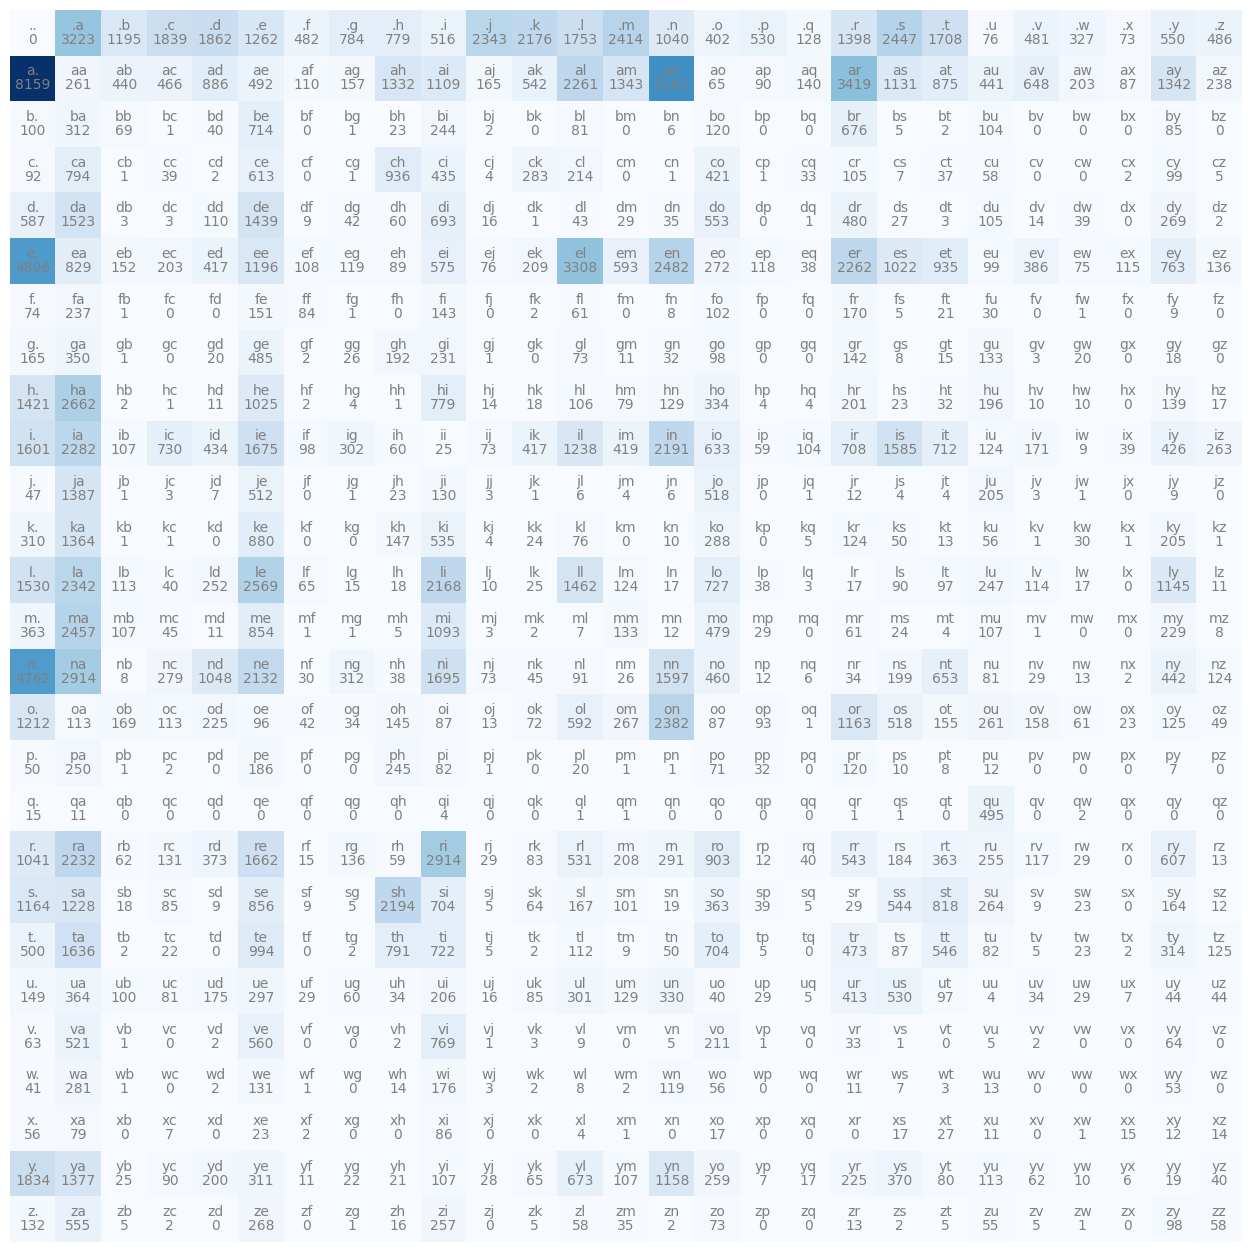

In [133]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap = 'Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='grey')
        plt.text(j, i, N[i,j].item(),  ha="center", va="top", color='gray')

plt.axis('off')

In [45]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p /= p.sum()
p
torch.multinomial(p,num_samples=100,replacement=True,generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [39]:
N[0]


tensor([   0, 3223, 1195, 1839, 1862, 1262,  482,  784,  779,  516, 2343, 2176,
        1753, 2414, 1040,  402,  530,  128, 1398, 2447, 1708,   76,  481,  327,
          73,  550,  486], dtype=torch.int32)

In [89]:
p = N[0].float()
p /= p.sum()
p

tensor([0.0000, 0.1065, 0.0395, 0.0607, 0.0615, 0.0417, 0.0159, 0.0259, 0.0257,
        0.0170, 0.0774, 0.0719, 0.0579, 0.0797, 0.0344, 0.0133, 0.0175, 0.0042,
        0.0462, 0.0808, 0.0564, 0.0025, 0.0159, 0.0108, 0.0024, 0.0182, 0.0161])

In [90]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1,replacement=True, generator=g).item()
itos[ix]

'c'

In [171]:
P = (N+1).float() # +1 for model smoothing
P.shape

torch.Size([27, 27])

In [172]:
P /= P.sum(1, keepdim=True)
P[0]

tensor([3.3002e-05, 1.0640e-01, 3.9471e-02, 6.0724e-02, 6.1483e-02, 4.1682e-02,
        1.5940e-02, 2.5907e-02, 2.5742e-02, 1.7062e-02, 7.7357e-02, 7.1846e-02,
        5.7886e-02, 7.9700e-02, 3.4355e-02, 1.3300e-02, 1.7524e-02, 4.2573e-03,
        4.6170e-02, 8.0789e-02, 5.6401e-02, 2.5412e-03, 1.5907e-02, 1.0825e-02,
        2.4422e-03, 1.8184e-02, 1.6072e-02])

In [174]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out=[]
    ix = 0

    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


cexze.
comasurarorikayha.
vinimittain.
llayn.
ka.


In [175]:
log_likelihood = 0.0
n = 0

for w in names:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')


log_likelihood=tensor(-541928.5000)
nll=tensor(541928.5000)
2.4495604038238525


In [176]:
xs, ys = [], []

for w in names[:1]:
    chs=['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. a
a r
r i
i e
e l
l .


In [103]:
xs

tensor([ 0,  1, 18,  9,  5, 12])

In [106]:
ys

tensor([ 1, 18,  9,  5, 12,  0])

In [107]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [108]:
xenc.shape

torch.Size([6, 27])

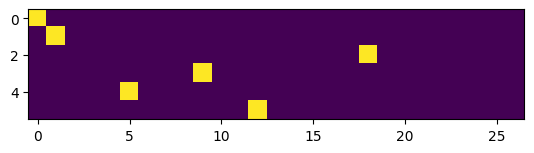

In [109]:
plt.imshow(xenc)

In [ ]:
W = torch.randn((27, 27))
xenc @ W


tensor([[ 2.0603,  0.2039,  0.4353, -0.1220, -0.4555,  1.1531,  0.1360,  1.3292,
          0.1239,  0.3020,  0.2292, -0.3633,  0.2146,  0.9276, -0.5126,  0.5573,
          0.3585,  1.0869, -1.0144,  0.0403,  1.5260, -0.0221, -0.9027, -0.4423,
         -0.4693,  1.3757,  0.1011],
        [-0.9247,  0.2876,  0.6191, -0.3493, -1.1684,  0.2086, -0.0667, -2.7126,
         -2.1112, -0.4144,  1.2244, -1.7565,  1.1000, -0.3671,  1.0837,  1.1586,
          0.2645, -0.6126,  0.0928,  0.2435,  1.3339,  1.3470,  0.7067,  0.1462,
          0.0638, -0.4400,  1.4418],
        [-0.9813, -1.4660, -0.9353,  1.1074, -1.1525, -2.7527,  0.4489, -0.9673,
         -0.0310, -0.4540, -0.7485,  0.9103,  0.1650, -0.7484, -1.8544, -1.4776,
          0.1914,  0.0509, -0.9110,  0.2065, -1.2382, -0.3256, -0.8332, -0.7587,
          0.1988,  0.8165,  0.5795],
        [ 0.4918,  1.3035, -0.4843,  0.5708, -0.8503,  0.9665, -0.5427, -0.1816,
          1.3879,  0.5736, -0.7514, -0.2238,  1.4835,  0.1824,  0.0653, -0.0350

In [123]:
logits = xenc @ W
counts = logits.exp()
probs = counts/counts.sum(1, keepdim=True)
probs

tensor([[0.1605, 0.0251, 0.0316, 0.0181, 0.0130, 0.0648, 0.0234, 0.0773, 0.0231,
         0.0277, 0.0257, 0.0142, 0.0253, 0.0517, 0.0122, 0.0357, 0.0293, 0.0606,
         0.0074, 0.0213, 0.0941, 0.0200, 0.0083, 0.0131, 0.0128, 0.0809, 0.0226],
        [0.0094, 0.0317, 0.0442, 0.0168, 0.0074, 0.0293, 0.0223, 0.0016, 0.0029,
         0.0157, 0.0810, 0.0041, 0.0715, 0.0165, 0.0703, 0.0758, 0.0310, 0.0129,
         0.0261, 0.0304, 0.0903, 0.0915, 0.0483, 0.0275, 0.0254, 0.0153, 0.1006],
        [0.0156, 0.0096, 0.0163, 0.1260, 0.0131, 0.0027, 0.0652, 0.0158, 0.0403,
         0.0264, 0.0197, 0.1034, 0.0491, 0.0197, 0.0065, 0.0095, 0.0504, 0.0438,
         0.0167, 0.0512, 0.0121, 0.0301, 0.0181, 0.0195, 0.0508, 0.0942, 0.0743],
        [0.0336, 0.0756, 0.0127, 0.0364, 0.0088, 0.0540, 0.0119, 0.0171, 0.0823,
         0.0365, 0.0097, 0.0164, 0.0906, 0.0247, 0.0219, 0.0198, 0.0383, 0.0202,
         0.0240, 0.0589, 0.0050, 0.0166, 0.0760, 0.0429, 0.0237, 0.0232, 0.1191],
        [0.0339, 0.0345,

In [124]:
probs[0].sum()

tensor(1.0000)

In [198]:
xs, ys = [], []

for w in names:
    chs=['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        #print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(len(xs))
print(len(ys))

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

221235
221235


In [199]:

for i in range(100):
    #forward pass 
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts/counts.sum(1, keepdims=True)

    #loss
    loss = -probs[torch.arange(len(ys)), ys].log().mean()
    #print(loss.item())

    #backward pass
    W.grad = None
    loss.backward()

    #update gradient
    W.data += -5 * W.grad

print(loss.item())


2.6957876682281494


In [203]:
for i in range(5):
    out = []
    ix = 0
    while True:

        #props = P[ix]
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts/counts.sum(1, keepdims=True)

        ix = torch.multinomial(props,num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


ze.
nrrl.
nl.
lm.
n.
